# Classification de Radios Pulmonaires — Pipeline Complet Amélioré
## Détection : Normal · Pneumonia · COVID-19 · Tuberculosis

Ce notebook intègre toutes les améliorations recommandées :
- **Data augmentation renforcée** avec les stats ImageNet
- **Équilibrage** via `WeightedRandomSampler`
- **Fine-tuning progressif** en 3 phases
- **Scheduler** `CosineAnnealingLR` + **early stopping** avec patience
- **Métriques médicales** : ROC-AUC, F1, courbes loss/accuracy
- **Grad-CAM** pour la visualisation des activations


## 1. Configuration de l'accès Kaggle

In [ ]:
# Upload du fichier kaggle.json depuis votre machine locale
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"iliaskh","key":"45da9434d957c9120f19b57b4e933541"}'}

In [ ]:
# Installation du répertoire Kaggle et sécurisation des permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## 2. Téléchargement des datasets

In [ ]:
# Chest X-Ray (Normal + Pneumonia) — Paul Mooney
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# COVID-19 Radiography Database — Tawsifur Rahman
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database

# Tuberculosis Chest X-Ray — Tawsifur Rahman
!kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:16<00:00, 149MB/s]

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
100% 778M/778M [00:04<00:00, 195MB/s]

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
100% 663M/663M [00:04<00:00, 148MB/s]



In [ ]:
# Décompression des archives dans /content/
!unzip -q chest-xray-pneumonia.zip
!unzip -q covid19-radiography-database.zip
!unzip -q tuberculosis-tb-chest-xray-dataset.zip

## 3. Construction du dataset unifié

In [ ]:
import os, shutil, random, glob
import numpy as np
from PIL import Image, ImageEnhance, ImageOps
import torchvision.transforms.functional as TF
import torch

base    = "/content/final_dataset"
classes = ["Normal", "Pneumonia", "COVID", "Tuberculosis"]
splits  = ["train", "val", "test"]

# Suppression et recréation propre de l'arborescence
if os.path.exists(base):
    shutil.rmtree(base)
for split in splits:
    for c in classes:
        os.makedirs(f"{base}/{split}/{c}", exist_ok=True)

# ── Collecte des fichiers bruts ─────────────────────────────────────────────
normal_files    = glob.glob("/content/chest_xray/train/NORMAL/*.jpeg")
pneumonia_files = glob.glob("/content/chest_xray/train/PNEUMONIA/*.jpeg")
covid_files     = glob.glob("/content/**/COVID*/**/*.*", recursive=True)
tb_files        = glob.glob("/content/**/Tuberculosis*/**/*.*", recursive=True)

print("Images brutes disponibles :")
print(f"  Normal      : {len(normal_files)}")
print(f"  Pneumonia   : {len(pneumonia_files)}")
print(f"  COVID       : {len(covid_files)}")
print(f"  Tuberculosis: {len(tb_files)}")

# ── Cible d'équilibrage ─────────────────────────────────────────────────────
# On prend le minimum entre la taille naturelle de chaque classe et un cap
# fixé à 2500 images par classe — assez pour entraîner sans déséquilibre.
# Tuberculosis est la classe la plus rare (~489) : elle définit le plancher.
TARGET = 2500  # images par classe après équilibrage

def augment_image(img_path, out_dir, base_name, n_extra):
    """
    Génère n_extra versions augmentées d'une image et les sauvegarde.
    Utilisé pour sur-échantillonner les classes sous-représentées
    sans dupliquer les mêmes pixels (chaque augmentation est unique).
    """
    try:
        img = Image.open(img_path).convert("RGB").resize((224, 224))
    except Exception:
        return

    augmentations = [
        lambda i: i.transpose(Image.FLIP_LEFT_RIGHT),
        lambda i: i.rotate(random.uniform(-15, 15), resample=Image.BILINEAR, fillcolor=(128,128,128)),
        lambda i: ImageEnhance.Brightness(i).enhance(random.uniform(0.75, 1.25)),
        lambda i: ImageEnhance.Contrast(i).enhance(random.uniform(0.8, 1.2)),
        lambda i: i.rotate(random.uniform(-10, 10)).transpose(Image.FLIP_LEFT_RIGHT),
        lambda i: ImageEnhance.Sharpness(i).enhance(random.uniform(0.5, 1.5)),
        lambda i: i.transpose(Image.FLIP_LEFT_RIGHT).rotate(random.uniform(-8, 8)),
        lambda i: ImageEnhance.Color(i).enhance(random.uniform(0.8, 1.2)),
    ]

    random.shuffle(augmentations)
    for k, aug in enumerate(augmentations[:n_extra]):
        aug_img = aug(img)
        aug_img.save(f"{out_dir}/{base_name}_aug{k}.jpeg", "JPEG", quality=90)


def split_and_balance(files, cls_name, target=TARGET, seed=42):
    """
    1. Sous-échantillonne si la classe est sur-représentée (COVID).
    2. Sur-échantillonne par augmentation si la classe est sous-représentée
       (Tuberculosis, Normal).
    3. Répartit ensuite en train(70%) / val(15%) / test(15%).

    L'augmentation est appliquée UNIQUEMENT sur le split train
    pour ne pas contaminer val et test avec des images artificielles.
    """
    random.seed(seed)
    random.shuffle(files)

    # Sous-échantillonnage : on garde au plus `target` images originales
    files_used = files[:target] if len(files) > target else files[:]

    n = len(files_used)
    t_end = int(0.70 * n)
    v_end = int(0.85 * n)

    train_files = files_used[:t_end]
    val_files   = files_used[t_end:v_end]
    test_files  = files_used[v_end:]

    # Copie des fichiers originaux
    for f in train_files:
        shutil.copy(f, f"{base}/train/{cls_name}/")
    for f in val_files:
        shutil.copy(f, f"{base}/val/{cls_name}/")
    for f in test_files:
        shutil.copy(f, f"{base}/test/{cls_name}/")

    # Sur-échantillonnage train uniquement si < target
    train_target = int(0.70 * target)
    n_existing   = len(train_files)
    n_needed     = train_target - n_existing

    if n_needed > 0:
        print(f"  {cls_name}: sur-échantillonnage train +{n_needed} images augmentées")
        pool = train_files * (n_needed // max(len(train_files), 1) + 2)
        random.shuffle(pool)
        for k, src_path in enumerate(pool[:n_needed]):
            base_name = f"syn_{k:05d}"
            out_dir   = f"{base}/train/{cls_name}"
            augment_image(src_path, out_dir, base_name, n_extra=1)

    return len(train_files) + max(0, n_needed), len(val_files), len(test_files)


# ── Application de l'équilibrage ────────────────────────────────────────────
print(f"\nCible par classe : {TARGET} images (avant split)")
print("Traitement en cours...\n")

results = {}
results["Normal"]       = split_and_balance(normal_files,    "Normal",       target=TARGET)
results["Pneumonia"]    = split_and_balance(pneumonia_files, "Pneumonia",    target=TARGET)
results["COVID"]        = split_and_balance(covid_files,     "COVID",        target=TARGET)
results["Tuberculosis"] = split_and_balance(tb_files,        "Tuberculosis", target=TARGET)

# ── Vérification finale ─────────────────────────────────────────────────────
print("\n=== Répartition finale équilibrée ===")
for split in splits:
    print(f"\n{split.upper()}")
    total = 0
    for c in classes:
        n = len(os.listdir(f"{base}/{split}/{c}"))
        total += n
        bar = '#' * (n // 30)
        print(f"  {c:15s}: {n:5d}  {bar}")
    print(f"  {'TOTAL':15s}: {total:5d}")


Images brutes disponibles :
  Normal      : 1341
  Pneumonia   : 3875
  COVID       : 49567
  Tuberculosis: 700

Cible par classe : 2500 images (avant split)
Traitement en cours...

  Normal: sur-échantillonnage train +812 images augmentées
  Tuberculosis: sur-échantillonnage train +1261 images augmentées

=== Répartition finale équilibrée ===

TRAIN
  Normal         :  1750  ##########################################################
  Pneumonia      :  1750  ##########################################################
  COVID          :  1707  ########################################################
  Tuberculosis   :  1750  ##########################################################
  TOTAL          :  6957

VAL
  Normal         :   201  ######
  Pneumonia      :   375  ############
  COVID          :   374  ############
  Tuberculosis   :   106  ###
  TOTAL          :  1056

TEST
  Normal         :   202  ######
  Pneumonia      :   375  ############
  COVID          :   372  #########

## 4. Imports et configuration GPU

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import cv2
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 5. Transformations et DataLoaders

In [ ]:
# Chemins des splits
base      = "/content/final_dataset"
train_dir = base + "/train"
val_dir   = base + "/val"
test_dir  = base + "/test"

# ── Statistiques ImageNet (beaucoup mieux que [0.5]*3 pour ResNet pré-entraîné)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Entraînement : augmentation renforcée pour améliorer la généralisation
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),                          # crop aléatoire plus efficace que Resize direct
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),                       # légères rotations (radios pas toujours centrées)
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # variations de contraste (radios variables)
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# ── Validation / Test : uniquement redimensionnement + normalisation
eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

In [ ]:
# Chargement des datasets
train_data = datasets.ImageFolder(train_dir, transform=train_tf)
val_data   = datasets.ImageFolder(val_dir,   transform=eval_tf)
test_data  = datasets.ImageFolder(test_dir,  transform=eval_tf)

classes     = train_data.classes
num_classes = len(classes)
print("Classes:", classes)

# ── WeightedRandomSampler : rééquilibre les batches sans supprimer d'images
#    Principe : probabilité de tirage inversement proportionnelle à la fréquence
targets      = np.array(train_data.targets)
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
sample_weights = class_weights[targets]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)
print("\nPoids de classe (sampler):", dict(zip(classes, class_weights.round(4))))

# DataLoaders
# Note : shuffle=False car le sampler gère déjà le mélange
train_loader = DataLoader(train_data, batch_size=32, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False,    num_workers=2, pin_memory=True)

Classes: ['COVID', 'Normal', 'Pneumonia', 'Tuberculosis']

Poids de classe (sampler): {'COVID': np.float64(0.0006), 'Normal': np.float64(0.0006), 'Pneumonia': np.float64(0.0006), 'Tuberculosis': np.float64(0.0006)}


## 6. Définition du modèle (ResNet-50 + Transfer Learning)

In [ ]:
def build_model(num_classes, freeze_backbone=True):
    """
    Construit un ResNet-50 pré-entraîné avec une nouvelle tête de classification.

    freeze_backbone=True  → Phase A : seule la tête est entraînée
    freeze_backbone=False → Phase B/C : fine-tuning du backbone
    """
    model = models.resnet50(pretrained=True)

    if freeze_backbone:
        # Gèle tout le backbone
        for p in model.parameters():
            p.requires_grad = False

    # Nouvelle tête : Linear(2048→512) + BN + ReLU + Dropout + Linear(512→N)
    # BatchNorm1d ajouté pour stabiliser l'entraînement de la tête
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    return model.to(device)

model = build_model(num_classes, freeze_backbone=True)

# Résumé des paramètres
total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres totaux    : {total:,}")
print(f"Paramètres entraînables : {trainable:,} ({100*trainable/total:.1f}%)")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


Paramètres totaux    : 24,560,196
Paramètres entraînables : 1,052,164 (4.3%)


In [ ]:
# Poids de classe pour la loss (en plus du sampler, renforce encore l'équilibre)
from sklearn.utils.class_weight import compute_class_weight

y = np.array(train_data.targets)
cw = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
criterion_weights = torch.tensor(cw, dtype=torch.float).to(device)
print("Poids CrossEntropy:", dict(zip(classes, cw.round(3))))

# Fonction de perte et optimiseur initial (Phase A — tête seule)
criterion = nn.CrossEntropyLoss(weight=criterion_weights)
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)

# Scheduler : réduit le lr d'un facteur 10 quand la val_loss stagne 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=3
)

Poids CrossEntropy: {'COVID': np.float64(1.019), 'Normal': np.float64(0.994), 'Pneumonia': np.float64(0.994), 'Tuberculosis': np.float64(0.994)}


## 7. Fonctions d'entraînement et d'évaluation

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Une époque d'entraînement. Retourne (loss_moy, accuracy)."""
    model.train()
    total_loss = correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        # Gradient clipping pour éviter les explosions de gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Évaluation sans gradient. Retourne (loss_moy, accuracy)."""
    model.eval()
    total_loss = correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out  = model(x)
        loss = criterion(out, y)
        total_loss += loss.item() * x.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


def run_training(model, optimizer, scheduler, criterion, epochs, phase_name,
                 patience=5, save_path="/content/best_model.pth"):
    """
    Boucle d'entraînement complète avec :
      - Suivi des courbes loss/accuracy
      - Early stopping (patience epochs sans amélioration)
      - Sauvegarde du meilleur modèle
    """
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"\n{'='*60}")
    print(f"  {phase_name}")
    print(f"{'='*60}")

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        # Mise à jour du scheduler
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(va_loss)
        else:
            scheduler.step()

        lr_now = optimizer.param_groups[0]['lr']
        marker = ""
        if va_loss < best_val_loss:
            best_val_loss = va_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            marker = " ✓ sauvegardé"

        else:
            patience_counter += 1
            marker = f" ({patience_counter}/{patience})"

        print(f"Ep {ep:02d} | lr={lr_now:.2e} | "
              f"Train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
              f"Val loss={va_loss:.4f} acc={va_acc:.3f}{marker}")

        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping après {ep} epochs (patience={patience})")
            break

    return history

## 8. Entraînement — Phase A : tête seule (backbone gelé)

In [ ]:
# Phase A : seule la nouvelle tête fc est entraînée.
# Le backbone ResNet extrait des features ImageNet génériques.
# Convergence rapide, peu de risque de sur-apprentissage.

optimizer_A = optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_A = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_A, mode='min', factor=0.3, patience=3
)

hist_A = run_training(
    model, optimizer_A, scheduler_A, criterion,
    epochs=15,
    phase_name="Phase A — backbone gelé, tête seule",
    patience=5,
    save_path="/content/best_model_A.pth"
)


  Phase A — backbone gelé, tête seule
Ep 01 | lr=1.00e-03 | Train loss=0.4179 acc=0.843 | Val loss=0.5111 acc=0.820 ✓ sauvegardé
Ep 02 | lr=1.00e-03 | Train loss=0.3339 acc=0.884 | Val loss=0.3913 acc=0.864 ✓ sauvegardé
Ep 03 | lr=1.00e-03 | Train loss=0.3189 acc=0.892 | Val loss=0.4097 acc=0.869 (1/5)
Ep 04 | lr=1.00e-03 | Train loss=0.3067 acc=0.898 | Val loss=0.4169 acc=0.877 (2/5)
Ep 05 | lr=1.00e-03 | Train loss=0.3113 acc=0.895 | Val loss=0.3218 acc=0.894 ✓ sauvegardé
Ep 06 | lr=1.00e-03 | Train loss=0.2922 acc=0.900 | Val loss=0.3638 acc=0.890 (1/5)
Ep 07 | lr=1.00e-03 | Train loss=0.2904 acc=0.901 | Val loss=0.4698 acc=0.859 (2/5)
Ep 08 | lr=1.00e-03 | Train loss=0.2874 acc=0.903 | Val loss=0.4406 acc=0.861 (3/5)
Ep 09 | lr=3.00e-04 | Train loss=0.2702 acc=0.909 | Val loss=0.5760 acc=0.820 (4/5)
Ep 10 | lr=3.00e-04 | Train loss=0.2562 acc=0.914 | Val loss=0.3967 acc=0.872 (5/5)

Early stopping après 10 epochs (patience=5)


## 9. Entraînement — Phase B : fine-tuning layer3 + layer4

In [ ]:
# Rechargement du meilleur modèle de la Phase A
model.load_state_dict(torch.load("/content/best_model_A.pth"))

# Dégel de layer3 et layer4 seulement (les couches les plus spécialisées)
# Les couches layer1 et layer2 restent gelées : elles capturent des features
# bas niveau (bords, textures) qui sont génériques et n'ont pas besoin d'adaptation.
for name, param in model.named_parameters():
    if any(layer in name for layer in ["layer3", "layer4", "fc"]):
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable_B = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres entraînables Phase B : {trainable_B:,}")

# LR 10x plus faible pour ne pas détruire les features pré-entraînées
optimizer_B = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler_B = optim.lr_scheduler.CosineAnnealingLR(optimizer_B, T_max=15, eta_min=1e-6)

hist_B = run_training(
    model, optimizer_B, scheduler_B, criterion,
    epochs=15,
    phase_name="Phase B — layer3+layer4 dégelés",
    patience=5,
    save_path="/content/best_model_B.pth"
)

Paramètres entraînables Phase B : 23,115,268

  Phase B — layer3+layer4 dégelés
Ep 01 | lr=9.89e-05 | Train loss=0.2526 acc=0.921 | Val loss=0.2205 acc=0.930 ✓ sauvegardé
Ep 02 | lr=9.57e-05 | Train loss=0.1812 acc=0.948 | Val loss=0.2940 acc=0.903 (1/5)
Ep 03 | lr=9.05e-05 | Train loss=0.1600 acc=0.954 | Val loss=0.2124 acc=0.926 ✓ sauvegardé
Ep 04 | lr=8.36e-05 | Train loss=0.1358 acc=0.961 | Val loss=0.2101 acc=0.943 ✓ sauvegardé
Ep 05 | lr=7.52e-05 | Train loss=0.1373 acc=0.962 | Val loss=0.2904 acc=0.926 (1/5)
Ep 06 | lr=6.58e-05 | Train loss=0.1046 acc=0.970 | Val loss=0.2101 acc=0.947 (2/5)
Ep 07 | lr=5.57e-05 | Train loss=0.1098 acc=0.969 | Val loss=0.2127 acc=0.941 (3/5)
Ep 08 | lr=4.53e-05 | Train loss=0.0933 acc=0.975 | Val loss=0.1976 acc=0.948 ✓ sauvegardé
Ep 09 | lr=3.52e-05 | Train loss=0.0830 acc=0.977 | Val loss=0.2318 acc=0.955 (1/5)
Ep 10 | lr=2.58e-05 | Train loss=0.0899 acc=0.975 | Val loss=0.2220 acc=0.945 (2/5)
Ep 11 | lr=1.74e-05 | Train loss=0.0749 acc=0.980 | 

## 10. Entraînement — Phase C : fine-tuning complet (optionnel)

In [ ]:
# Phase C optionnelle : dégèle tout le réseau avec un lr très faible.
# Recommandé uniquement si le dataset est suffisamment grand (>5000 images/classe)
# et si la Phase B n'a pas encore convergé.

model.load_state_dict(torch.load("/content/best_model_B.pth"))

# Dégel de tous les paramètres
for p in model.parameters():
    p.requires_grad = True

trainable_C = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres entraînables Phase C : {trainable_C:,}")

optimizer_C = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler_C = optim.lr_scheduler.CosineAnnealingLR(optimizer_C, T_max=10, eta_min=1e-7)

hist_C = run_training(
    model, optimizer_C, scheduler_C, criterion,
    epochs=10,
    phase_name="Phase C — backbone entier dégelé",
    patience=4,
    save_path="/content/best_model_final.pth"
)

Paramètres entraînables Phase C : 24,560,196

  Phase C — backbone entier dégelé
Ep 01 | lr=9.76e-06 | Train loss=0.0858 acc=0.978 | Val loss=0.2174 acc=0.944 ✓ sauvegardé
Ep 02 | lr=9.05e-06 | Train loss=0.0757 acc=0.980 | Val loss=0.2174 acc=0.948 ✓ sauvegardé
Ep 03 | lr=7.96e-06 | Train loss=0.0775 acc=0.981 | Val loss=0.2224 acc=0.947 (1/4)
Ep 04 | lr=6.58e-06 | Train loss=0.0713 acc=0.980 | Val loss=0.1998 acc=0.953 ✓ sauvegardé
Ep 05 | lr=5.05e-06 | Train loss=0.0581 acc=0.984 | Val loss=0.2250 acc=0.955 (1/4)
Ep 06 | lr=3.52e-06 | Train loss=0.0672 acc=0.980 | Val loss=0.2259 acc=0.955 (2/4)
Ep 07 | lr=2.14e-06 | Train loss=0.0537 acc=0.985 | Val loss=0.2297 acc=0.953 (3/4)
Ep 08 | lr=1.05e-06 | Train loss=0.0705 acc=0.980 | Val loss=0.2223 acc=0.954 (4/4)

Early stopping après 8 epochs (patience=4)


## 11. Visualisation des courbes d'entraînement

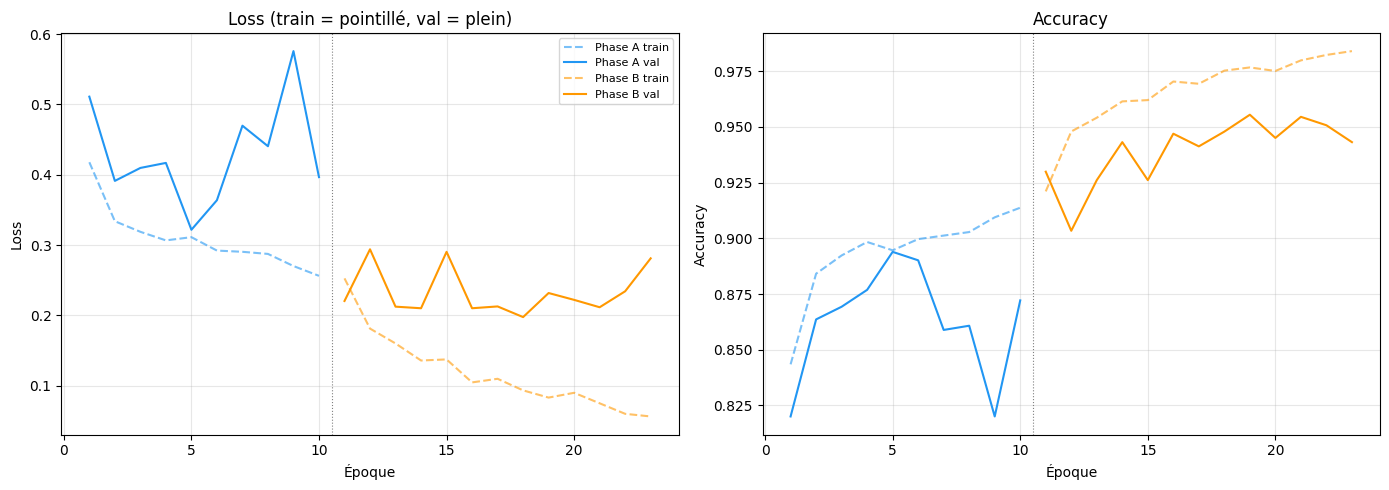

In [ ]:
def plot_history(histories, labels):
    """
    Trace les courbes loss et accuracy pour plusieurs phases d'entraînement.
    Permet de détecter le sur-apprentissage (val_loss > train_loss en divergence).
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2196F3', '#FF9800', '#4CAF50']

    offset = 0
    for hist, label, color in zip(histories, labels, colors):
        n = len(hist['train_loss'])
        x = range(offset + 1, offset + n + 1)

        axes[0].plot(x, hist['train_loss'], '--', color=color, alpha=0.6, label=f'{label} train')
        axes[0].plot(x, hist['val_loss'],   '-',  color=color,            label=f'{label} val')
        axes[1].plot(x, hist['train_acc'],  '--', color=color, alpha=0.6)
        axes[1].plot(x, hist['val_acc'],    '-',  color=color)

        # Ligne de séparation entre phases
        if offset > 0:
            for ax in axes:
                ax.axvline(x=offset + 0.5, color='gray', linestyle=':', linewidth=0.8)
        offset += n

    axes[0].set_title("Loss (train = pointillé, val = plein)")
    axes[0].set_xlabel("Époque")
    axes[0].set_ylabel("Loss")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Époque")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("/content/training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()

# Adapter selon les phases exécutées
plot_history(
    [hist_A, hist_B],          # Remplacer par [hist_A, hist_B, hist_C] si Phase C exécutée
    ["Phase A", "Phase B"]
)

## 12. Évaluation finale sur le jeu de test

In [ ]:
# Chargement du meilleur modèle global
# (remplacer par best_model_final.pth si la Phase C a été exécutée)
best_path = "/content/best_model_B.pth"
model.load_state_dict(torch.load(best_path))
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

Test Loss : 0.1728
Test Accuracy : 0.9611 (96.11%)


In [ ]:
@torch.no_grad()
def get_predictions(model, loader):
    """
    Collecte toutes les prédictions, labels vrais et probabilités softmax
    sur un DataLoader. Retourne trois tableaux numpy.
    """
    model.eval()
    all_y, all_pred, all_proba = [], [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        proba  = F.softmax(logits, dim=1).cpu().numpy()
        pred   = logits.argmax(1).cpu().numpy()
        all_y.extend(y.numpy())
        all_pred.extend(pred)
        all_proba.append(proba)
    return (np.array(all_y),
            np.array(all_pred),
            np.vstack(all_proba))

y_true, y_pred, y_proba = get_predictions(model, test_loader)

print("\n=== Rapport de classification ===")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))


=== Rapport de classification ===
              precision    recall  f1-score   support

       COVID     0.9860    0.9462    0.9657       372
      Normal     0.8834    0.9752    0.9271       202
   Pneumonia     0.9730    0.9627    0.9678       375
Tuberculosis     1.0000    0.9810    0.9904       105

    accuracy                         0.9611      1054
   macro avg     0.9606    0.9663    0.9627      1054
weighted avg     0.9631    0.9611    0.9615      1054



## 13. ROC-AUC par classe (métrique médicale clé)

ROC-AUC macro : 0.9918


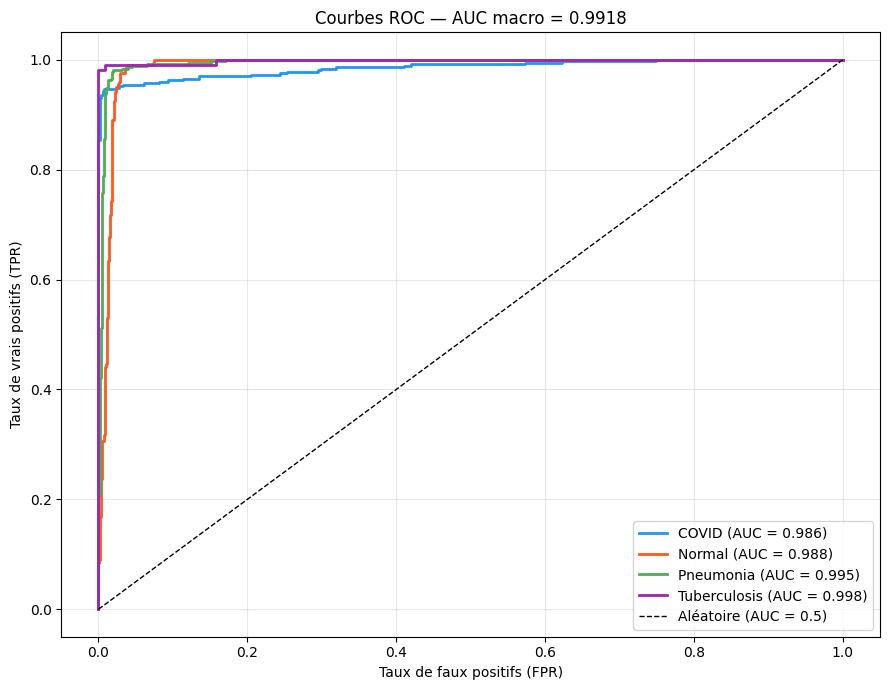

In [ ]:
# ROC-AUC est la métrique de référence en imagerie médicale car elle est
# indépendante du seuil de décision et robuste aux déséquilibres de classes.
# Un AUC de 1.0 = parfait, 0.5 = aléatoire.

# Binarisation des labels pour le calcul one-vs-rest
y_bin = label_binarize(y_true, classes=range(num_classes))

# AUC global (macro = moyenne non pondérée sur toutes les classes)
auc_macro = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='macro')
print(f"ROC-AUC macro : {auc_macro:.4f}")

# Tracé des courbes ROC par classe
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for i, (cls, color) in enumerate(zip(classes, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    auc_i = roc_auc_score(y_bin[:, i], y_proba[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{cls} (AUC = {auc_i:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label="Aléatoire (AUC = 0.5)")
ax.set_title(f"Courbes ROC — AUC macro = {auc_macro:.4f}")
ax.set_xlabel("Taux de faux positifs (FPR)")
ax.set_ylabel("Taux de vrais positifs (TPR)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()

## 14. Matrice de confusion normalisée

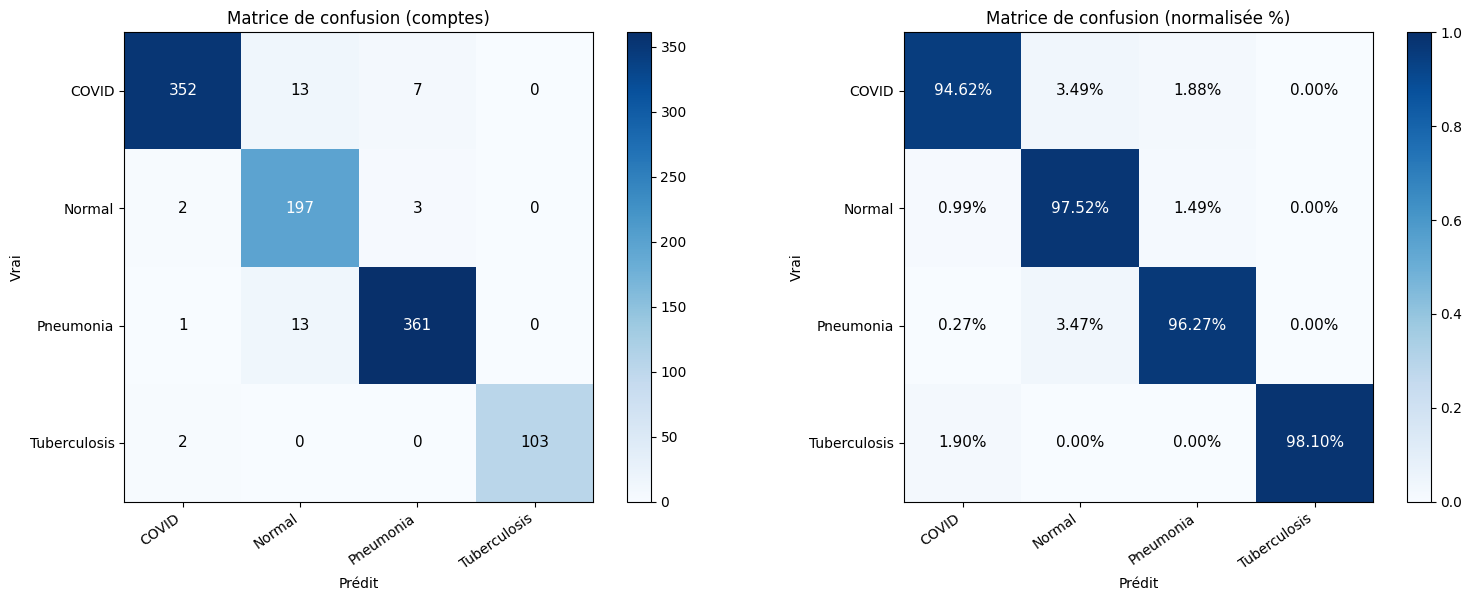

In [ ]:
# Matrice de confusion normalisée en % par ligne (vraie classe).
# La diagonale = taux de bonne classification par classe.
# Les erreurs hors diagonale révèlent les confusions fréquentes
# (ex: Pneumonie confondue avec COVID).

conf_matrix = confusion_matrix(y_true, y_pred)
cm_norm = conf_matrix.astype(float) / conf_matrix.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, matrix, title, fmt in [
    (axes[0], conf_matrix,      "Matrice de confusion (comptes)",     "d"),
    (axes[1], cm_norm, "Matrice de confusion (normalisée %)", ".2%")
]:
    im = ax.imshow(matrix, interpolation='nearest',
                   cmap='Blues', vmin=0, vmax=(1 if fmt == ".2%" else None))
    plt.colorbar(im, ax=ax)
    ax.set(xticks=range(num_classes), yticks=range(num_classes),
           xticklabels=classes, yticklabels=classes,
           title=title, xlabel="Prédit", ylabel="Vrai")
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
    thresh = matrix.max() / 2.0
    for i in range(num_classes):
        for j in range(num_classes):
            val = f"{matrix[i,j]:{fmt}}"
            color = "white" if matrix[i, j] > thresh else "black"
            ax.text(j, i, val, ha="center", va="center", color=color, fontsize=11)

plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

## 15. Grad-CAM — Visualisation des zones activées

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


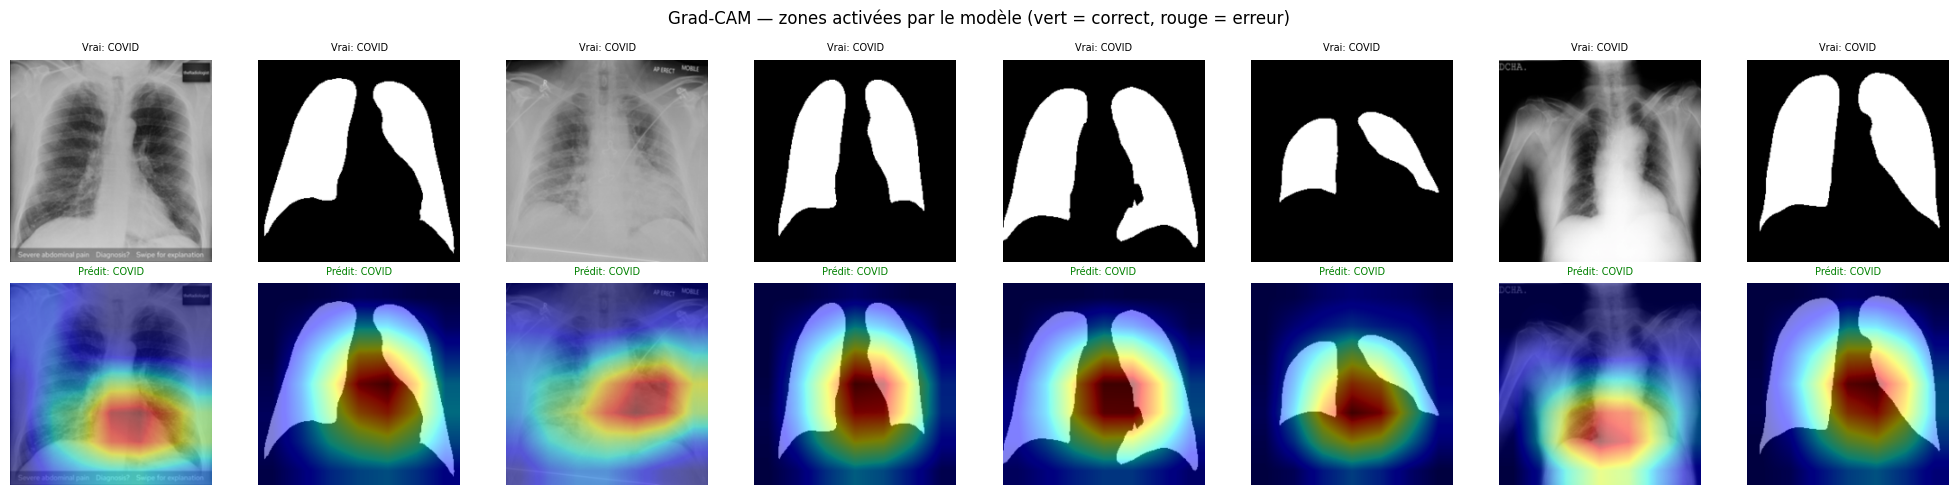

In [ ]:
# Grad-CAM (Gradient-weighted Class Activation Mapping)
# Technique d'explainabilité : met en évidence les zones de la radio
# que le modèle a utilisées pour prendre sa décision.
# Indispensable en médical pour vérifier que le modèle regarde les poumons
# et non du bruit de fond (bordures, texte, artefacts).

import matplotlib.cm as cm # Ajout de cette ligne pour importer le module cm

class GradCAM:
    """
    Implémentation de Grad-CAM pour la dernière couche convolutive de ResNet-50.
    Principe : calcule le gradient de la classe prédite par rapport aux
    feature maps de la dernière couche, puis pondère ces maps par le gradient.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        # Hooks pour capturer les activations et gradients en passant
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, x, class_idx=None):
        """Génère la carte de chaleur Grad-CAM pour une image tenseur."""
        self.model.eval()
        x = x.unsqueeze(0).to(device)

        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(1).item()

        # Rétropropagation sur la classe ciblée uniquement
        self.model.zero_grad()
        one_hot = torch.zeros_like(logits)
        one_hot[0, class_idx] = 1.0
        logits.backward(gradient=one_hot)

        # Poids = gradient moyen par canal (global average pooling)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        # Normalisation et redimensionnement en 224×224
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (224, 224))
        return cam, class_idx


# Attachement du hook sur la dernière couche convolutive de ResNet-50
grad_cam = GradCAM(model, model.layer4[-1].conv3)


def denormalize(tensor):
    """Inverse la normalisation ImageNet pour affichage."""
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std  = torch.tensor(STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


# Sélection d'un batch du jeu de test
test_iter = iter(test_loader)
imgs, labels = next(test_iter)

# Affichage de 8 exemples avec leur carte Grad-CAM
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(20, 5))

for idx in range(n_show):
    img_t = imgs[idx]
    true_label = classes[labels[idx]]

    cam, pred_idx = grad_cam.generate(img_t)
    pred_label = classes[pred_idx]

    img_np = denormalize(img_t)

    # Superposition de la heatmap sur la radio originale
    heatmap = cm.jet(cam)[..., :3]
    overlay = 0.5 * img_np + 0.5 * heatmap

    axes[0, idx].imshow(img_np)
    axes[0, idx].axis('off')
    color = 'green' if pred_label == true_label else 'red'
    axes[0, idx].set_title(f"Vrai: {true_label}", fontsize=7)

    axes[1, idx].imshow(overlay)
    axes[1, idx].axis('off')
    axes[1, idx].set_title(f"Prédit: {pred_label}", fontsize=7, color=color)

axes[0, 0].set_ylabel("Radio originale", fontsize=9)
axes[1, 0].set_ylabel("Grad-CAM", fontsize=9)
plt.suptitle("Grad-CAM — zones activées par le modèle (vert = correct, rouge = erreur)")
plt.tight_layout()
plt.savefig("/content/gradcam.png", dpi=150, bbox_inches='tight')
plt.show()

## 16. Résumé des résultats

In [ ]:
# Tableau récapitulatif de toutes les métriques
from sklearn.metrics import f1_score, precision_score, recall_score

print("=" * 55)
print("       RÉSUMÉ DES PERFORMANCES")
print("=" * 55)
print(f"  Accuracy           : {test_acc*100:.2f}%")
print(f"  ROC-AUC (macro)    : {auc_macro:.4f}")
print(f"  F1 (macro)         : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"  Précision (macro)  : {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"  Rappel (macro)     : {recall_score(y_true, y_pred, average='macro'):.4f}")
print("=" * 55)
print()
print("F1 par classe :")
for cls, f1 in zip(classes, f1_score(y_true, y_pred, average=None)):
    bar = '#' * int(f1 * 20)
    print(f"  {cls:15s} : {f1:.4f}  {bar}")

print()
print("Fichiers sauvegardés :")
for f in ["/content/best_model_B.pth", "/content/training_curves.png",
          "/content/roc_curves.png", "/content/confusion_matrix.png",
          "/content/gradcam.png"]:
    exists = "OK" if os.path.exists(f) else "manquant"
    print(f"  {f:45s} [{exists}]")

       RÉSUMÉ DES PERFORMANCES
  Accuracy           : 96.11%
  ROC-AUC (macro)    : 0.9918
  F1 (macro)         : 0.9627
  Précision (macro)  : 0.9606
  Rappel (macro)     : 0.9663

F1 par classe :
  COVID           : 0.9657  ###################
  Normal          : 0.9271  ##################
  Pneumonia       : 0.9678  ###################
  Tuberculosis    : 0.9904  ###################

Fichiers sauvegardés :
  /content/best_model_B.pth                     [OK]
  /content/training_curves.png                  [OK]
  /content/roc_curves.png                       [OK]
  /content/confusion_matrix.png                 [OK]
  /content/gradcam.png                          [OK]
